# Module 3 — Product Portfolio Analysis

**Purpose:** Identify revenue concentration, mix dynamics, and return risk by product. Informs SKU prioritisation for the forecasting model and the portfolio strategy slide in the CEO presentation.

**Inputs:** `base_sales_enriched.parquet`, `outlet_sku_monthly_demand.parquet`

---

## Analysis Roadmap

1. **Revenue & Volume Contribution** — Pareto analysis, HHI concentration
2. **Growth Rates by Product** — CAGR per product line, 2×2 strategic matrix
3. **Mix Shift Over Time** — Stacked bar charts, structural dynamics
4. **Return Analysis** — Return rates by category/brand, chi-square test
5. **SKU Demand Continuity** — Classification into Continuous/Intermittent/Lumpy
6. **Export Results** — Summary tables and visualizations for downstream use

In [4]:
import sys
from pathlib import Path

In [9]:
ls ../../..

DS Lead_Assessment.zip         pipelines/
EDA/                           requirements.txt
Sr. Data Scientist Assessment/ src/
conf/                          test/
data/                          venv/
docs/


In [5]:
# PROJECT_ROOT = Path.cwd().parent.parent
PROJECT_ROOT = Path("../../..")
sys.path.insert(0, str(PROJECT_ROOT))

In [6]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import warnings
from scipy import stats
from scipy.stats import chi2_contingency
import os

warnings.filterwarnings('ignore')

# Set visualization defaults
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Import McKinsey theme
from src.viz.mckinsey_theme import (
    MCKINSEY_RC, BG_DARK, TEXT_WHITE, TEXT_DARK, GRID_COLOR,
    LINE_NOMINAL, LINE_VOLUME, LINE_REAL, HIGHLIGHT,
    create_mckinsey_figure, add_end_label
)

# Apply McKinsey theme
matplotlib.rcParams.update(MCKINSEY_RC)

print("Libraries imported successfully.")

Libraries imported successfully.


## Section 1: Load Analytical Datasets

Load the pre-processed analytical datasets from Module 0. These datasets contain fully zero-filled, exhaustive primary keys.

In [10]:
# Define data paths
intermediate_path = "../../../data/Intermediate"

# Load analytical datasets
print("Loading analytical datasets from Module 0...")

base_sales_enriched = pd.read_parquet(os.path.join(intermediate_path, "base_sales_enriched.parquet"))
outlet_sku_monthly_demand = pd.read_parquet(os.path.join(intermediate_path, "outlet_sku_monthly_demand.parquet"))

print(f"✓ base_sales_enriched: {base_sales_enriched.shape}")
print(f"  Columns: {list(base_sales_enriched.columns)[:5]}...")
print(f"\n✓ outlet_sku_monthly_demand: {outlet_sku_monthly_demand.shape}")
print(f"  Columns: {list(outlet_sku_monthly_demand.columns)[:8]}...")

# Validate key columns exist
required_cols_base = ['item_code', 'net_sales', 'quantity', 'document_type', 
                      'product_category', 'product_line', 'brand']
required_cols_demand = ['item_code', 'year_month', 'product_category', 'product_line', 
                        'brand', 'gross_sales', 'gross_quantity', 'return_quantity', 'n_invoices', 'n_returns']

assert all(col in base_sales_enriched.columns for col in required_cols_base), \
    f"Missing columns in base_sales_enriched: {set(required_cols_base) - set(base_sales_enriched.columns)}"
assert all(col in outlet_sku_monthly_demand.columns for col in required_cols_demand), \
    f"Missing columns in outlet_sku_monthly_demand: {set(required_cols_demand) - set(outlet_sku_monthly_demand.columns)}"

print("\n✓ All required columns validated.")

Loading analytical datasets from Module 0...
✓ base_sales_enriched: (6799893, 18)
  Columns: ['document_date', 'documnet_number', 'outlet_id', 'territory_id', 'document_type']...

✓ outlet_sku_monthly_demand: (123104457, 18)
  Columns: ['outlet_id', 'item_code', 'year_month', 'net_quantity', 'net_sales', 'gross_quantity', 'gross_sales', 'return_quantity']...

✓ All required columns validated.


## Section 2: Revenue and Volume Contribution (Pareto Analysis)

Aggregate gross sales and quantity by SKU to identify revenue concentration and Pareto segments.

In [11]:
# Aggregate gross_sales by item_code
sku_revenue = outlet_sku_monthly_demand.groupby('item_code').agg({
    'gross_sales': 'sum',
    'gross_quantity': 'sum',
    'product_category': 'first',
    'product_line': 'first',
    'brand': 'first'
}).reset_index()

# Sort by gross_sales descending and compute cumulative share
sku_revenue = sku_revenue.sort_values('gross_sales', ascending=False).reset_index(drop=True)
sku_revenue['revenue_share'] = sku_revenue['gross_sales'] / sku_revenue['gross_sales'].sum()
sku_revenue['cumulative_revenue_share'] = sku_revenue['revenue_share'].cumsum()
sku_revenue['sku_rank'] = range(1, len(sku_revenue) + 1)

# Pareto Segmentation
sku_revenue['pareto_segment'] = 'Long Tail'
sku_revenue.loc[sku_revenue['cumulative_revenue_share'] <= 0.80, 'pareto_segment'] = 'Core'
sku_revenue.loc[(sku_revenue['cumulative_revenue_share'] > 0.80) & 
                (sku_revenue['cumulative_revenue_share'] <= 0.95), 'pareto_segment'] = 'Growth'

# Summary statistics
print("=" * 80)
print("SKU REVENUE CONTRIBUTION SUMMARY")
print("=" * 80)
print(f"\nTotal SKUs: {len(sku_revenue)}")
print(f"Total Gross Sales: ${sku_revenue['gross_sales'].sum():,.0f}")
print(f"\nPareto Segmentation:")

pareto_summary = sku_revenue.groupby('pareto_segment').agg({
    'item_code': 'count',
    'gross_sales': 'sum',
    'revenue_share': 'sum'
}).rename(columns={'item_code': 'n_skus', 'gross_sales': 'total_sales', 'revenue_share': 'pct_revenue'})

pareto_summary['pct_revenue'] = (pareto_summary['pct_revenue'] * 100).round(2)
print(pareto_summary)

# Top 10 SKUs
print(f"\nTop 10 SKUs by Revenue:")
top_10 = sku_revenue.head(10)[['item_code', 'product_line', 'brand', 'gross_sales', 'revenue_share']]
top_10['revenue_share_pct'] = (top_10['revenue_share'] * 100).round(2)
print(top_10[['item_code', 'product_line', 'brand', 'gross_sales', 'revenue_share_pct']].to_string(index=False))

# Herfindahl-Hirschman Index (HHI)
hhi_sku = (sku_revenue['revenue_share'] ** 2).sum()
hhi_product_line = ((sku_revenue.groupby('product_line')['gross_sales'].sum() / sku_revenue['gross_sales'].sum()) ** 2).sum()
hhi_brand = ((sku_revenue.groupby('brand')['gross_sales'].sum() / sku_revenue['gross_sales'].sum()) ** 2).sum()

print(f"\n" + "=" * 80)
print("CONCENTRATION RISK (Herfindahl-Hirschman Index)")
print("=" * 80)
print(f"HHI at SKU level:          {hhi_sku:.4f} {'(HIGH concentration risk)' if hhi_sku > 0.25 else '(moderate)'}")
print(f"HHI at Product Line level: {hhi_product_line:.4f} {'(HIGH concentration risk)' if hhi_product_line > 0.25 else '(moderate)'}")
print(f"HHI at Brand level:        {hhi_brand:.4f} {'(HIGH concentration risk)' if hhi_brand > 0.25 else '(moderate)'}")
print(f"\nNote: HHI > 0.25 indicates high concentration; business revenue is dependent on few items.")

SKU REVENUE CONTRIBUTION SUMMARY

Total SKUs: 50
Total Gross Sales: $14,210,136,851

Pareto Segmentation:
                n_skus   total_sales  pct_revenue
pareto_segment                                   
Core                20  1.130690e+10        79.57
Growth              14  2.094583e+09        14.74
Long Tail           16  8.086543e+08         5.69

Top 10 SKUs by Revenue:
item_code product_line   brand  gross_sales  revenue_share_pct
pf0033301   prod_line3 brand_1 2.031794e+09              14.30
pf0033901   prod_line3 brand_1 1.425056e+09              10.03
pf0013701   prod_line5 brand_1 1.265734e+09               8.91
gf4001604  prod_line10 brand_1 6.201498e+08               4.36
wf2002404  prod_line19 brand_1 5.862394e+08               4.13
pf0033302   prod_line3 brand_1 5.512723e+08               3.88
tt0060101  prod_line22 brand_1 4.742079e+08               3.34
pf0053001   prod_line4 brand_1 4.706656e+08               3.31
tt0230106   prod_line7 brand_1 4.316492e+08         

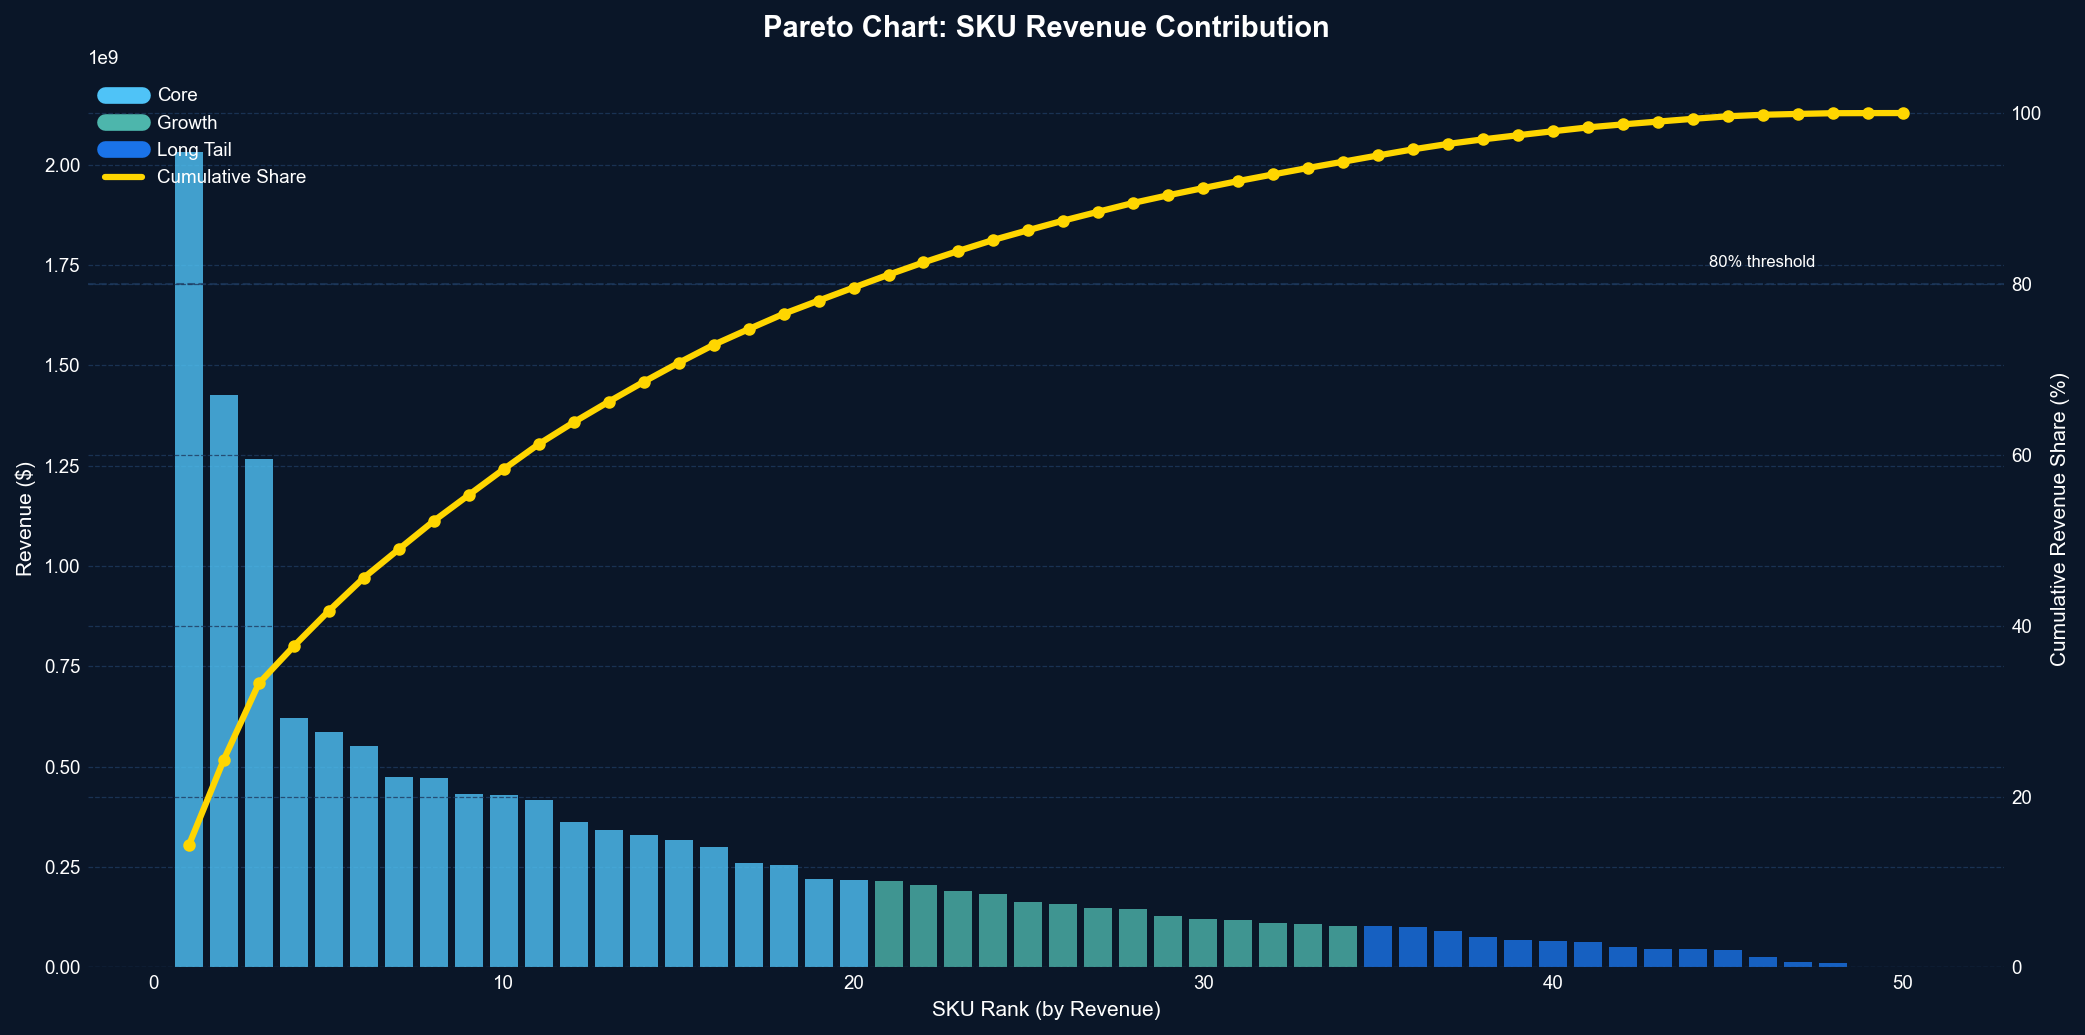

✓ Pareto chart generated and saved.


In [13]:
# Pareto Chart - McKinsey Style
fig, ax1 = create_mckinsey_figure(title="Pareto Chart: SKU Revenue Contribution")

# Define colors for Pareto segments
pareto_colors = {'Core': LINE_NOMINAL, 'Growth': LINE_VOLUME, 'Long Tail': LINE_REAL}
colors = [pareto_colors[seg] for seg in sku_revenue['pareto_segment']]

# Bar chart: revenue per SKU
ax1.bar(sku_revenue['sku_rank'], sku_revenue['gross_sales'], color=colors, alpha=0.8, zorder=3, width=0.8)
ax1.set_xlabel('SKU Rank (by Revenue)', color=TEXT_WHITE)
ax1.set_ylabel('Revenue ($)', color=TEXT_WHITE)
ax1.set_ylim(0, sku_revenue['gross_sales'].max() * 1.1)

# Create secondary y-axis for cumulative share
ax2 = ax1.twinx()
ax2.plot(sku_revenue['sku_rank'], sku_revenue['cumulative_revenue_share'] * 100,
         color=HIGHLIGHT, linewidth=3, marker='o', markersize=5, label='Cumulative Share (%)', zorder=5)
ax2.set_ylabel('Cumulative Revenue Share (%)', color=TEXT_WHITE)
ax2.set_ylim(0, 105)
ax2.axhline(y=80, color=GRID_COLOR, linestyle='--', linewidth=1, alpha=0.7, zorder=2)
ax2.text(sku_revenue['sku_rank'].iloc[-1] * 0.95, 82, '80% threshold', 
         fontsize=8, color=TEXT_WHITE, ha='right')

# Legend
handles = [Line2D([0], [0], color=LINE_NOMINAL, lw=8, label='Core'),
           Line2D([0], [0], color=LINE_VOLUME, lw=8, label='Growth'),
           Line2D([0], [0], color=LINE_REAL, lw=8, label='Long Tail'),
           Line2D([0], [0], color=HIGHLIGHT, lw=3, label='Cumulative Share')]
ax1.legend(handles=handles, loc='upper left', framealpha=0.0, fontsize=9)

plt.tight_layout()
plt.savefig('../../../data/output/m3_pareto_chart.png', bbox_inches='tight', facecolor=BG_DARK, dpi=150)
plt.show()

print("✓ Pareto chart generated and saved.")

## Section 3: Growth Rates by Product and Strategic Matrix

Calculate CAGR per product line and create a 2×2 strategic matrix (CAGR vs. revenue share).

In [14]:
# Prepare time series by product line
demand_by_line_month = outlet_sku_monthly_demand.groupby(['product_line', 'year_month']).agg({
    'gross_sales': 'sum',
    'gross_quantity': 'sum'
}).reset_index()

# Extract year from year_month string
demand_by_line_month['year'] = demand_by_line_month['year_month'].str[:4].astype(int)

# Aggregate to annual level
demand_by_line_year = demand_by_line_month.groupby(['product_line', 'year']).agg({
    'gross_sales': 'sum',
    'gross_quantity': 'sum'
}).reset_index()

# Calculate CAGR per product line
cagr_data = []
for product_line in demand_by_line_year['product_line'].unique():
    line_data = demand_by_line_year[demand_by_line_year['product_line'] == product_line].sort_values('year')
    
    if len(line_data) >= 2:
        start_sales = line_data['gross_sales'].iloc[0]
        end_sales = line_data['gross_sales'].iloc[-1]
        n_years = line_data['year'].iloc[-1] - line_data['year'].iloc[0]
        
        if start_sales > 0 and n_years > 0:
            cagr = (end_sales / start_sales) ** (1 / n_years) - 1
        else:
            cagr = 0
    else:
        cagr = 0
    
    # Get total revenue and share
    total_sales = demand_by_line_year[demand_by_line_year['product_line'] == product_line]['gross_sales'].sum()
    
    cagr_data.append({
        'product_line': product_line,
        'cagr': cagr,
        'total_sales': total_sales,
        'n_years': n_years
    })

cagr_df = pd.DataFrame(cagr_data)
cagr_df['revenue_share'] = cagr_df['total_sales'] / cagr_df['total_sales'].sum()

print("=" * 80)
print("PRODUCT LINE CAGR (Compound Annual Growth Rate)")
print("=" * 80)
print(cagr_df[['product_line', 'cagr', 'revenue_share', 'n_years']].sort_values('cagr', ascending=False).to_string(index=False))

# Calculate medians for quadrant split
median_cagr = cagr_df['cagr'].median()
median_share = cagr_df['revenue_share'].median()

print(f"\nMedian CAGR: {median_cagr:.1%}")
print(f"Median Revenue Share: {median_share:.1%}")

# Assign strategic quadrants
def assign_quadrant(row):
    if row['cagr'] >= median_cagr and row['revenue_share'] >= median_share:
        return 'Protect & Invest'
    elif row['cagr'] < median_cagr and row['revenue_share'] >= median_share:
        return 'Defend'
    elif row['cagr'] >= median_cagr and row['revenue_share'] < median_share:
        return 'Nurture'
    else:
        return 'Review/Exit'

cagr_df['quadrant'] = cagr_df.apply(assign_quadrant, axis=1)

print(f"\n" + "=" * 80)
print("STRATEGIC QUADRANT ASSIGNMENT")
print("=" * 80)
for quadrant in ['Protect & Invest', 'Defend', 'Nurture', 'Review/Exit']:
    lines = cagr_df[cagr_df['quadrant'] == quadrant]['product_line'].tolist()
    if lines:
        print(f"\n{quadrant}:")
        for line in lines:
            row = cagr_df[cagr_df['product_line'] == line].iloc[0]
            print(f"  - {line}: CAGR={row['cagr']:.1%}, Share={row['revenue_share']:.1%}")

PRODUCT LINE CAGR (Compound Annual Growth Rate)
product_line      cagr  revenue_share  n_years
 prod_line17  1.635507       0.021295        5
  prod_line2  0.000000       0.006757        5
 prod_line24  0.000000       0.006350        5
 prod_line21 -0.066300       0.012477        5
 prod_line11 -0.112370       0.056390        5
 prod_line18 -0.126192       0.029472        5
 prod_line13 -0.195290       0.007147        5
 prod_line12 -0.201525       0.043440        5
 prod_line26 -0.247460       0.008219        5
 prod_line22 -0.255419       0.054194        5
 prod_line15 -0.267295       0.007312        5
  prod_line1 -0.270056       0.005726        5
 prod_line14 -0.272695       0.027062        5
 prod_line16 -0.274429       0.011456        5
  prod_line9 -0.274998       0.007762        5
  prod_line5 -0.291464       0.114640        5
  prod_line3 -0.297187       0.312295        5
 prod_line25 -0.306183       0.007310        5
  prod_line4 -0.317993       0.033122        5
  prod_line8

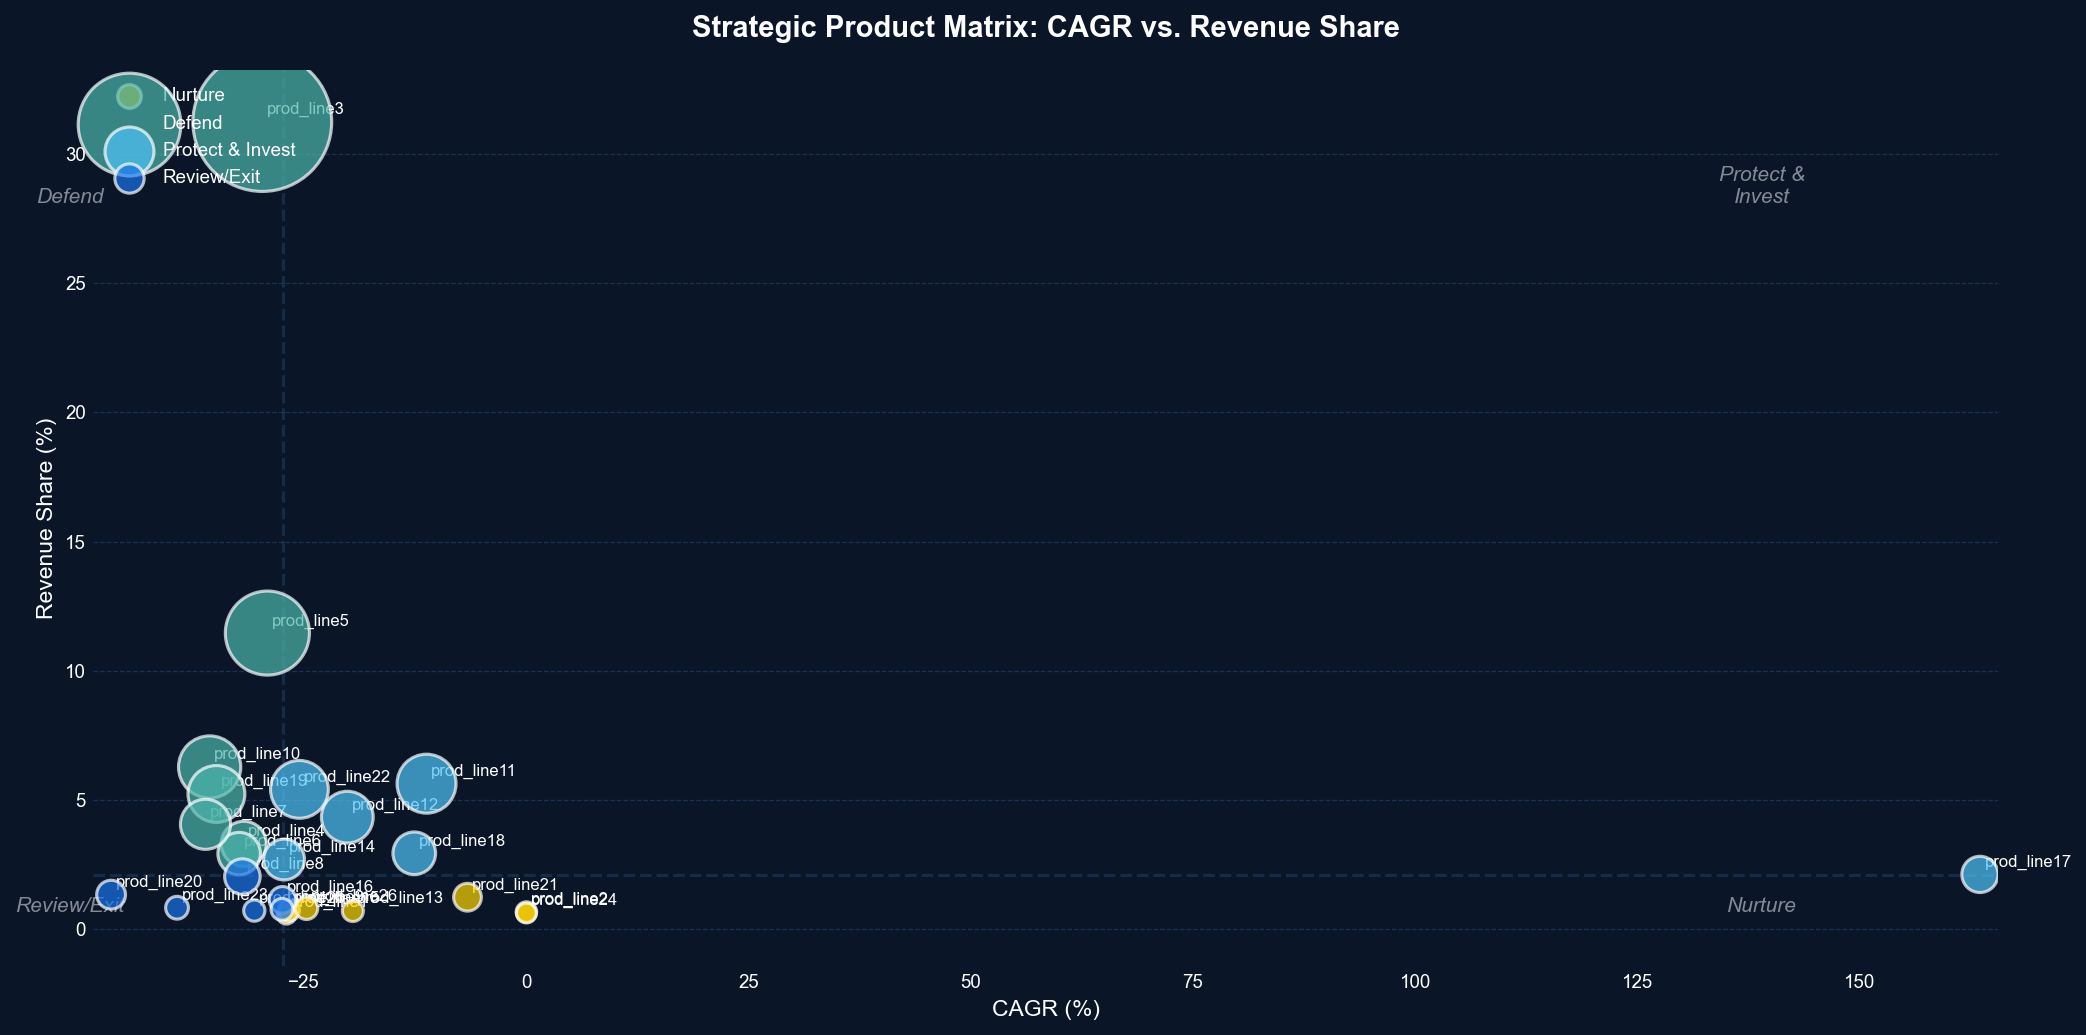


✓ Strategic matrix generated and saved.


In [16]:
# Strategic Matrix (2x2) - McKinsey Style
quadrant_colors_mk = {
    'Protect & Invest': LINE_NOMINAL,
    'Defend': LINE_VOLUME,
    'Nurture': HIGHLIGHT,
    'Review/Exit': LINE_REAL
}

fig, ax = create_mckinsey_figure(title="Strategic Product Matrix: CAGR vs. Revenue Share")

# Scatter plot with bubble sizes
for quadrant in cagr_df['quadrant'].unique():
    mask = cagr_df['quadrant'] == quadrant
    subset = cagr_df[mask]
    ax.scatter(subset['cagr'] * 100, subset['revenue_share'] * 100,
              s=subset['total_sales'] / 1e6,  # Scale bubble size
              alpha=0.7, color=quadrant_colors_mk[quadrant], label=quadrant, zorder=4,
              edgecolors=TEXT_WHITE, linewidth=1.5)
    
    # Add product line labels
    for idx, row in subset.iterrows():
        ax.text(row['cagr']*100 + 0.5, row['revenue_share']*100 + 0.3,
               row['product_line'], fontsize=8, color=TEXT_WHITE, ha='left')

# Add quadrant dividing lines
ax.axvline(x=median_cagr * 100, color=GRID_COLOR, linestyle='--', linewidth=1.5, alpha=0.6, zorder=2)
ax.axhline(y=median_share * 100, color=GRID_COLOR, linestyle='--', linewidth=1.5, alpha=0.6, zorder=2)

# Add quadrant labels
ax.text(cagr_df['cagr'].max()*100*0.85, cagr_df['revenue_share'].max()*100*0.9,
       'Protect &\nInvest', fontsize=10, color=TEXT_WHITE, ha='center', style='italic', alpha=0.5)
ax.text(cagr_df['cagr'].min()*100*1.1, cagr_df['revenue_share'].max()*100*0.9,
       'Defend', fontsize=10, color=TEXT_WHITE, ha='center', style='italic', alpha=0.5)
ax.text(cagr_df['cagr'].max()*100*0.85, cagr_df['revenue_share'].min()*100*1.2,
       'Nurture', fontsize=10, color=TEXT_WHITE, ha='center', style='italic', alpha=0.5)
ax.text(cagr_df['cagr'].min()*100*1.1, cagr_df['revenue_share'].min()*100*1.2,
       'Review/Exit', fontsize=10, color=TEXT_WHITE, ha='center', style='italic', alpha=0.5)

ax.set_xlabel('CAGR (%)', fontsize=11, color=TEXT_WHITE)
ax.set_ylabel('Revenue Share (%)', fontsize=11, color=TEXT_WHITE)
ax.set_xlim(cagr_df['cagr'].min()*100 - 2, cagr_df['cagr'].max()*100 + 2)
ax.set_ylim(cagr_df['revenue_share'].min()*100 - 2, cagr_df['revenue_share'].max()*100 + 2)
ax.legend(loc='upper left', framealpha=0.0, fontsize=9)

plt.tight_layout()
plt.savefig('../../../data/output/m3_strategic_matrix.png', bbox_inches='tight', facecolor=BG_DARK, dpi=150)
plt.show()

print("\n✓ Strategic matrix generated and saved.")

## Section 4: Product Mix Shift Over Time

Analyze structural changes in product category and brand mix by year.

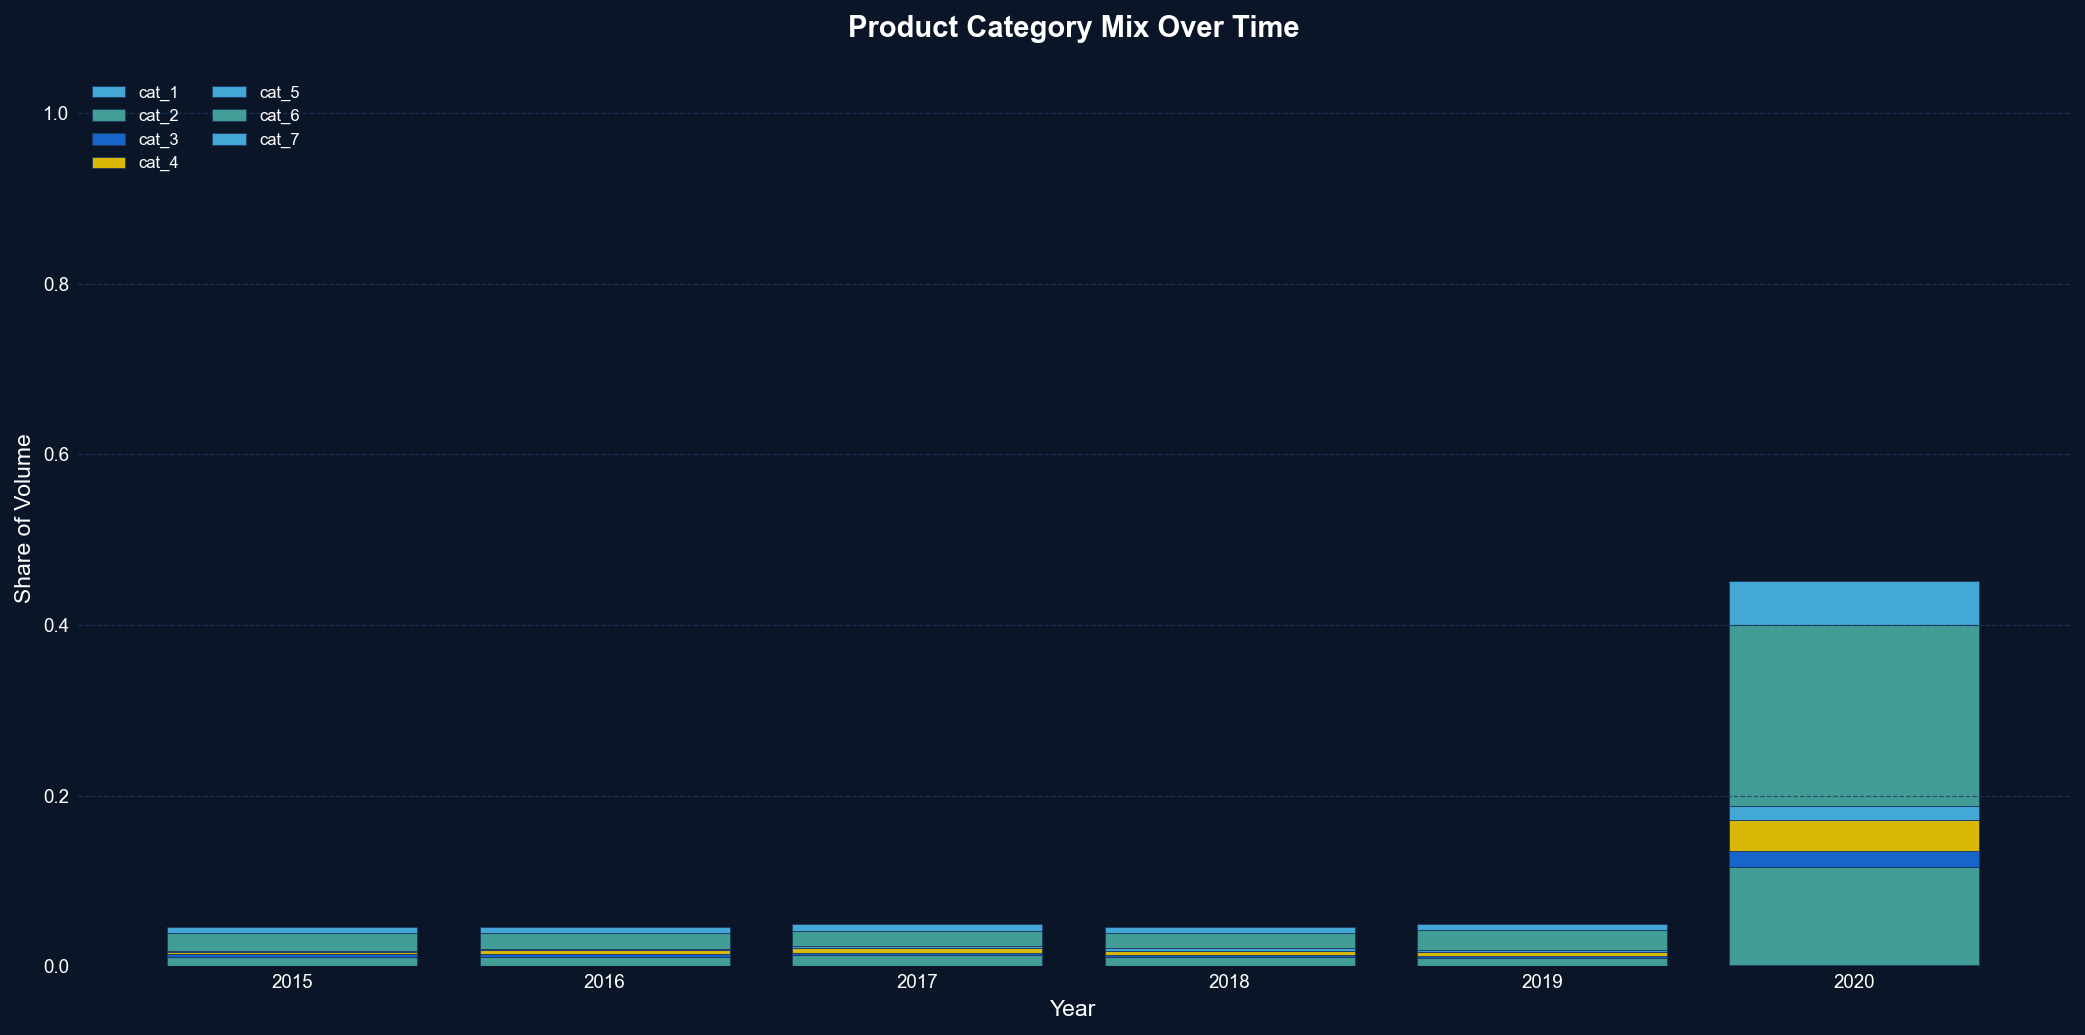

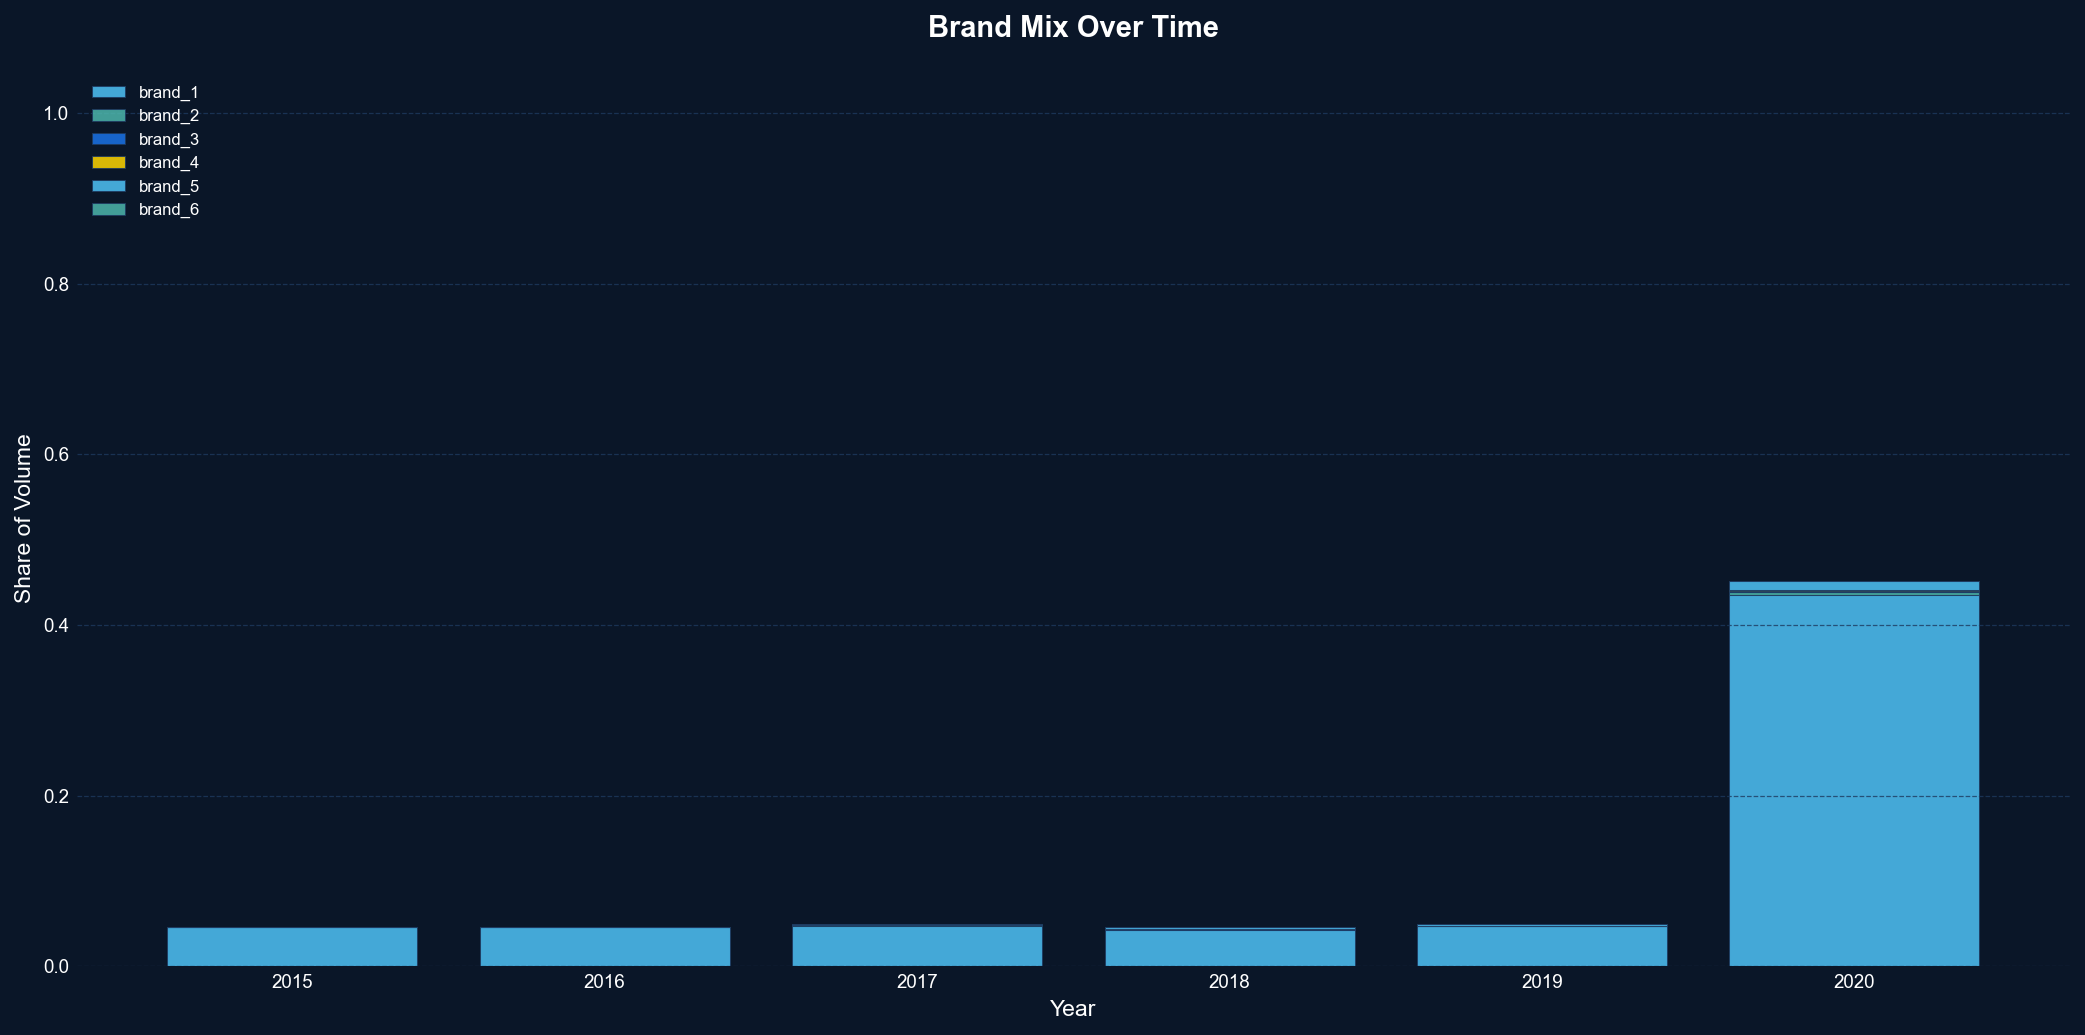


✓ Mix shift analysis complete and charts saved.


In [18]:
# Category and Brand Mix - McKinsey Style

# Color palette for segments
mix_colors = [LINE_NOMINAL, LINE_VOLUME, LINE_REAL, HIGHLIGHT, '#4FC3F7', '#4DB6AC']

# Prepare category and brand mix datasets
category_mix_year = outlet_sku_monthly_demand.groupby(['product_category', 'year_month']).agg({
    'gross_sales': 'sum',
    'gross_quantity': 'sum'
}).reset_index()
category_mix_year['year'] = category_mix_year['year_month'].str[:4].astype(int)
category_mix_year['sales_share'] = category_mix_year.groupby('year')['gross_quantity'].transform(lambda x: x / x.sum())

brand_mix_year = outlet_sku_monthly_demand.groupby(['brand', 'year_month']).agg({
    'gross_sales': 'sum',
    'gross_quantity': 'sum'
}).reset_index()
brand_mix_year['year'] = brand_mix_year['year_month'].str[:4].astype(int)
brand_mix_year['sales_share'] = brand_mix_year.groupby('year')['gross_quantity'].transform(lambda x: x / x.sum())

# === Category Mix ===
fig, ax = create_mckinsey_figure(title="Product Category Mix Over Time")

categories = sorted(category_mix_year['product_category'].unique())
years_unique = sorted(category_mix_year['year'].unique())

# Prepare stacked data
category_data = {}
for cat in categories:
    category_data[cat] = [category_mix_year[(category_mix_year['product_category'] == cat) & 
                                            (category_mix_year['year'] == yr)]['sales_share'].values[0] 
                         if len(category_mix_year[(category_mix_year['product_category'] == cat) & 
                                                  (category_mix_year['year'] == yr)]) > 0 else 0
                         for yr in years_unique]

# Stacked bar chart
bottom = np.zeros(len(years_unique))
for i, cat in enumerate(categories):
    ax.bar(years_unique, category_data[cat], bottom=bottom, label=cat, 
           color=mix_colors[i % len(mix_colors)], alpha=0.85, edgecolor=GRID_COLOR, linewidth=0.5)
    bottom += np.array(category_data[cat])

ax.set_xlabel('Year', fontsize=11, color=TEXT_WHITE)
ax.set_ylabel('Share of Volume', fontsize=11, color=TEXT_WHITE)
ax.set_ylim(0, 1.05)
ax.legend(loc='upper left', framealpha=0.0, fontsize=8, ncol=2)
ax.set_xticks(years_unique)

plt.tight_layout()
plt.savefig('../../../data/output/m3_category_mix.png', bbox_inches='tight', facecolor=BG_DARK, dpi=150)
plt.show()

# === Brand Mix ===
fig, ax = create_mckinsey_figure(title="Brand Mix Over Time")

brands = sorted(brand_mix_year['brand'].unique())

# Prepare stacked data
brand_data = {}
for brand in brands:
    brand_data[brand] = [brand_mix_year[(brand_mix_year['brand'] == brand) & 
                                        (brand_mix_year['year'] == yr)]['sales_share'].values[0] 
                        if len(brand_mix_year[(brand_mix_year['brand'] == brand) & 
                                             (brand_mix_year['year'] == yr)]) > 0 else 0
                        for yr in years_unique]

# Stacked bar chart
bottom = np.zeros(len(years_unique))
for i, brand in enumerate(brands):
    ax.bar(years_unique, brand_data[brand], bottom=bottom, label=brand, 
           color=mix_colors[i % len(mix_colors)], alpha=0.85, edgecolor=GRID_COLOR, linewidth=0.5)
    bottom += np.array(brand_data[brand])

ax.set_xlabel('Year', fontsize=11, color=TEXT_WHITE)
ax.set_ylabel('Share of Volume', fontsize=11, color=TEXT_WHITE)
ax.set_ylim(0, 1.05)
ax.legend(loc='upper left', framealpha=0.0, fontsize=8)
ax.set_xticks(years_unique)

plt.tight_layout()
plt.savefig('../../../data/output/m3_brand_mix.png', bbox_inches='tight', facecolor=BG_DARK, dpi=150)
plt.show()

print("\n✓ Mix shift analysis complete and charts saved.")

## Section 5: Return Analysis by Product Category and Brand

Compute return rates and identify categories with elevated return risk using statistical tests.

In [19]:
# Return rates by category and brand
return_by_category = outlet_sku_monthly_demand.groupby('product_category').agg({
    'return_quantity': 'sum',
    'gross_quantity': 'sum',
    'n_returns': 'sum',
    'n_invoices': 'sum'
}).reset_index()

return_by_category['return_rate'] = return_by_category['return_quantity'] / \
    (return_by_category['return_quantity'] + return_by_category['gross_quantity'] + 1e-9)

return_by_brand = outlet_sku_monthly_demand.groupby('brand').agg({
    'return_quantity': 'sum',
    'gross_quantity': 'sum',
    'n_returns': 'sum',
    'n_invoices': 'sum'
}).reset_index()

return_by_brand['return_rate'] = return_by_brand['return_quantity'] / \
    (return_by_brand['return_quantity'] + return_by_brand['gross_quantity'] + 1e-9)

# Overall statistics
overall_return_rate = (return_by_category['return_quantity'].sum() / 
                       (return_by_category['return_quantity'].sum() + return_by_category['gross_quantity'].sum()))

print("=" * 80)
print("RETURN RATE ANALYSIS BY CATEGORY")
print("=" * 80)
print(f"\nOverall Return Rate: {overall_return_rate:.2%}")
print(f"  (Out of {return_by_category['gross_quantity'].sum():,.0f} gross units, " +
      f"{return_by_category['return_quantity'].sum():,.0f} were returned)")

print("\nReturn Rate by Category:")
cat_return_display = return_by_category.sort_values('return_rate', ascending=False)[
    ['product_category', 'return_rate', 'return_quantity', 'gross_quantity', 'n_returns']
].copy()
cat_return_display['return_rate_pct'] = (cat_return_display['return_rate'] * 100).round(2)
print(cat_return_display[['product_category', 'return_rate_pct', 'return_quantity', 'gross_quantity']].to_string(index=False))

# Z-score flagging for categories
mean_return = return_by_category['return_rate'].mean()
std_return = return_by_category['return_rate'].std()
return_by_category['z_score'] = (return_by_category['return_rate'] - mean_return) / (std_return + 1e-9)
return_by_category['flag'] = return_by_category['z_score'] > 2

print(f"\nCategories with Elevated Return Risk (z-score > 2):")
elevated = return_by_category[return_by_category['flag']]
if len(elevated) > 0:
    for _, row in elevated.iterrows():
        print(f"  - {row['product_category']}: {row['return_rate']:.2%} " +
              f"(z-score: {row['z_score']:.2f}, {row['return_quantity']:.0f} units)")
else:
    print("  None detected")

print("\n" + "=" * 80)
print("RETURN RATE ANALYSIS BY BRAND")
print("=" * 80)

print("\nReturn Rate by Brand:")
brand_return_display = return_by_brand.sort_values('return_rate', ascending=False)[
    ['brand', 'return_rate', 'return_quantity', 'gross_quantity']
].copy()
brand_return_display['return_rate_pct'] = (brand_return_display['return_rate'] * 100).round(2)
print(brand_return_display[['brand', 'return_rate_pct', 'return_quantity', 'gross_quantity']].to_string(index=False))

# Chi-square test: return rate independence from category
# Build contingency table: invoices vs returns by category
contingency_table = outlet_sku_monthly_demand.groupby('product_category').agg({
    'n_invoices': 'sum',
    'n_returns': 'sum'
})

chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print(f"\n" + "=" * 80)
print("CHI-SQUARE TEST: Return Rate Independence from Category")
print("=" * 80)
print(f"H₀: Return rate is independent of product category")
print(f"Chi-square statistic: {chi2:.4f}")
print(f"P-value: {p_value:.6f}")
print(f"Degrees of freedom: {dof}")

if p_value < 0.05:
    print(f"✓ REJECT H₀ (p < 0.05): Return risk is significantly associated with product category.")
    print("  → Category-specific return adjustments should be applied to demand signals.")
else:
    print(f"✓ FAIL TO REJECT H₀ (p ≥ 0.05): Return rate appears independent of category.")
    print("  → Use overall return rate for all categories.")

RETURN RATE ANALYSIS BY CATEGORY

Overall Return Rate: 9.05%
  (Out of 319,396,025 gross units, 31,796,376 were returned)

Return Rate by Category:
product_category  return_rate_pct  return_quantity  gross_quantity
           cat_2            11.80         13036966        97431798
           cat_3             9.16          1767119        17526847
           cat_1             8.49            86369          930536
           cat_4             8.32          2179477        24022998
           cat_6             7.87         11074579       129611208
           cat_7             6.87          2938430        39843452
           cat_5             6.64           713436        10029186

Categories with Elevated Return Risk (z-score > 2):
  None detected

RETURN RATE ANALYSIS BY BRAND

Return Rate by Brand:
  brand  return_rate_pct  return_quantity  gross_quantity
brand_2            10.42           438578         3768815
brand_1             9.08         30847512       308834637
brand_5            

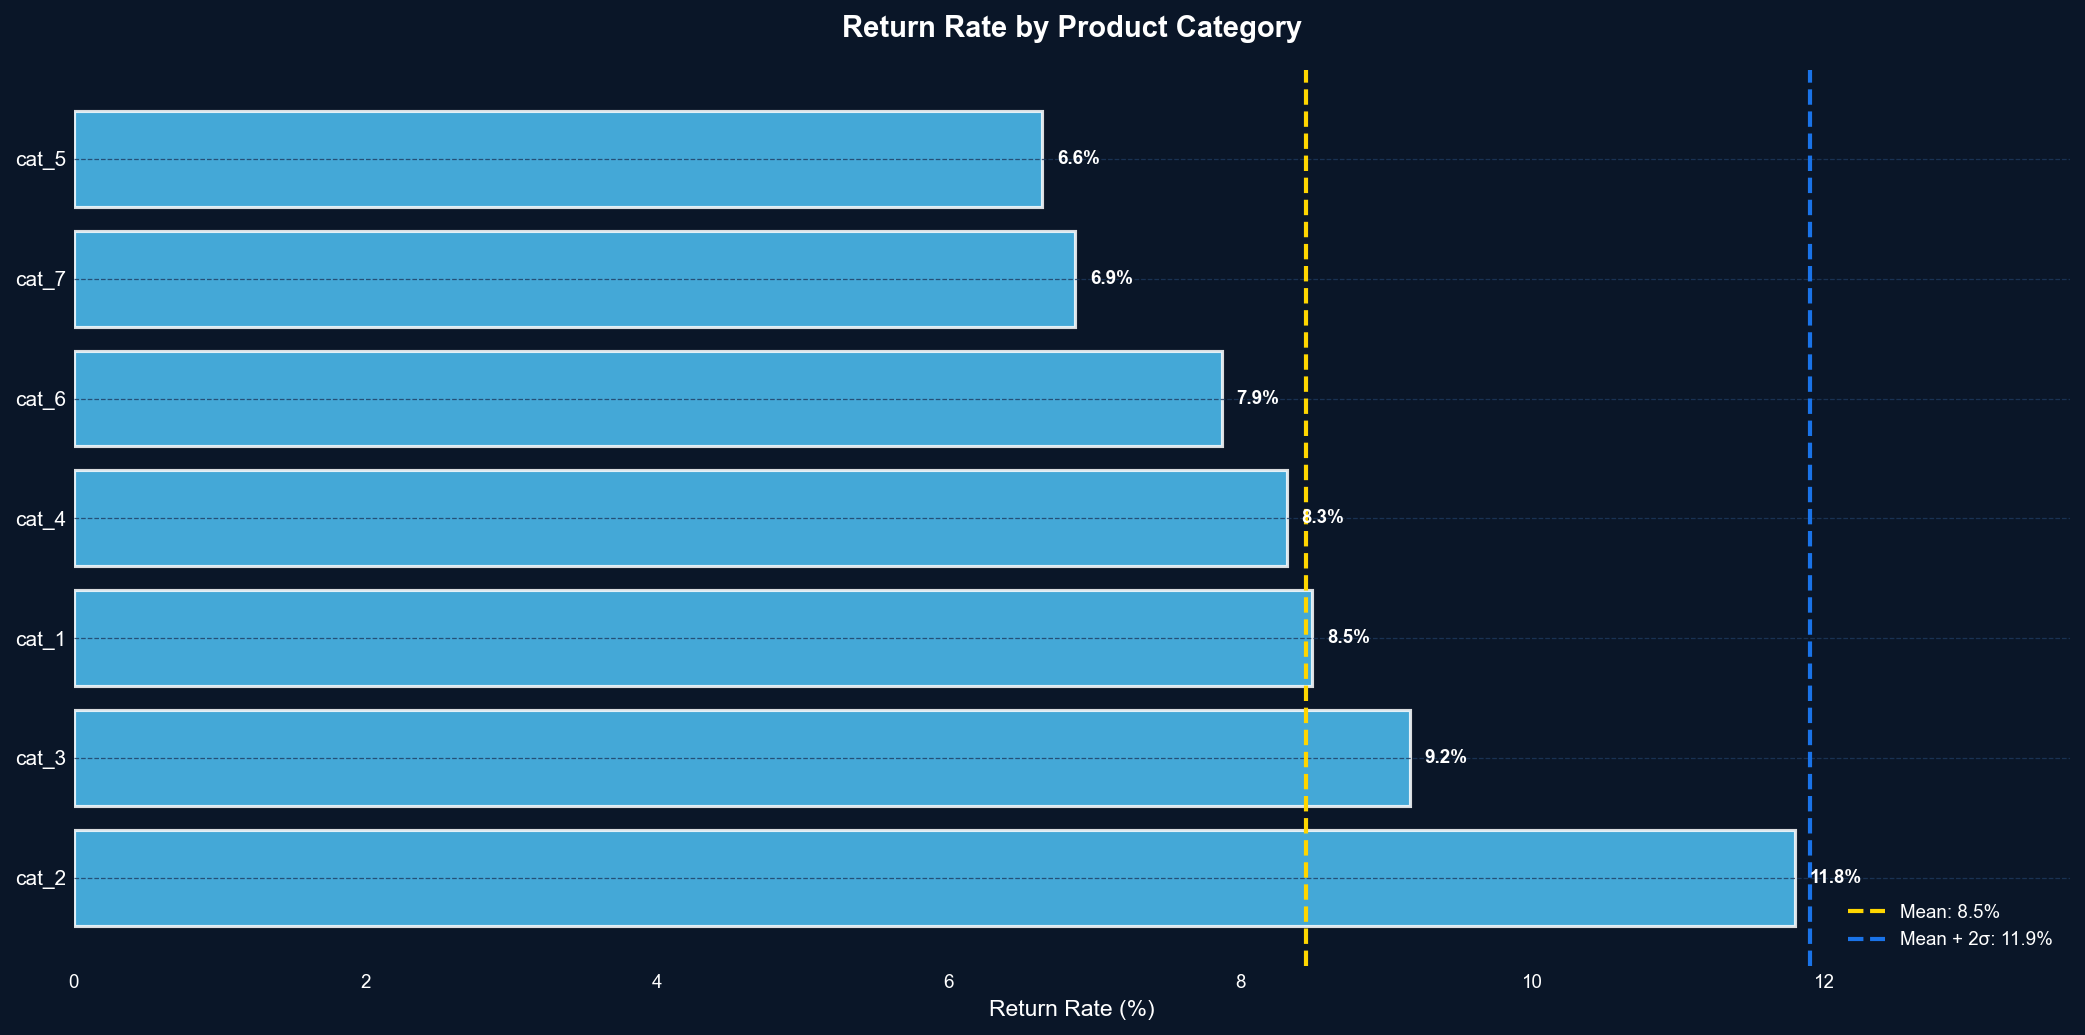


✓ Return analysis complete and chart saved.


In [20]:
# Return rate by category - McKinsey Style
fig, ax = create_mckinsey_figure(title="Return Rate by Product Category")

return_sorted = return_by_category.sort_values('return_rate', ascending=False)
x_pos = np.arange(len(return_sorted))

# Bar chart
bars = ax.barh(x_pos, return_sorted['return_rate'] * 100, color=LINE_NOMINAL, alpha=0.85, 
               edgecolor=TEXT_WHITE, linewidth=1.5)

# Add value labels
for i, (idx, row) in enumerate(return_sorted.iterrows()):
    ax.text(row['return_rate']*100 + 0.1, i, f"{row['return_rate']*100:.1f}%", 
           va='center', fontsize=9, color=TEXT_WHITE, fontweight='bold')

# Add mean and threshold lines
ax.axvline(x=mean_return * 100, color=HIGHLIGHT, linestyle='--', linewidth=2, 
          label=f'Mean: {mean_return*100:.1f}%', zorder=2)
ax.axvline(x=(mean_return + 2*std_return) * 100, color=LINE_REAL, linestyle='--', linewidth=2,
          label=f'Mean + 2σ: {(mean_return + 2*std_return)*100:.1f}%', zorder=2)

ax.set_yticks(x_pos)
ax.set_yticklabels(return_sorted['product_category'], fontsize=10)
ax.set_xlabel('Return Rate (%)', fontsize=11, color=TEXT_WHITE)
ax.set_xlim(0, (mean_return + 2*std_return) * 100 * 1.15)
ax.legend(loc='lower right', framealpha=0.0, fontsize=9)

plt.tight_layout()
plt.savefig('../../../data/output/m3_return_by_category.png', bbox_inches='tight', facecolor=BG_DARK, dpi=150)
plt.show()

print("\n✓ Return analysis complete and chart saved.")

## Section 6: SKU Demand Continuity Classification

Classify SKUs into Continuous, Intermittent, and Lumpy demand patterns based on activity and volatility.

In [21]:
# Aggregate to national SKU grain (sum across all outlets/territories)
sku_demand_monthly = outlet_sku_monthly_demand.groupby(['item_code', 'year_month']).agg({
    'gross_quantity': 'sum',
    'product_category': 'first',
    'product_line': 'first',
    'brand': 'first'
}).reset_index()

# Compute demand metrics per SKU
sku_continuity = []
for item_code in sku_demand_monthly['item_code'].unique():
    sku_data = sku_demand_monthly[sku_demand_monthly['item_code'] == item_code].sort_values('year_month')
    
    # Total months available
    n_months_available = sku_demand_monthly['year_month'].nunique()
    
    # Active months (gross_quantity > 0)
    active_months = (sku_data['gross_quantity'] > 0).sum()
    activity_rate = active_months / n_months_available if n_months_available > 0 else 0
    
    # CV: coefficient of variation (std / mean) over active months only
    active_data = sku_data[sku_data['gross_quantity'] > 0]['gross_quantity']
    if len(active_data) > 1:
        cv = active_data.std() / active_data.mean() if active_data.mean() > 0 else 0
    else:
        cv = 0
    
    # Classify: Continuous / Intermittent / Lumpy
    # Continuous: active >= 80% of months AND CV < 0.5
    # Intermittent: active 20-80% OR CV 0.5-1.0
    # Lumpy: active < 20% OR CV > 1.0
    
    if activity_rate >= 0.80 and cv < 0.5:
        demand_class = 'Continuous'
    elif activity_rate < 0.20 or cv > 1.0:
        demand_class = 'Lumpy'
    else:
        demand_class = 'Intermittent'
    
    sku_continuity.append({
        'item_code': item_code,
        'product_category': sku_data['product_category'].iloc[0],
        'product_line': sku_data['product_line'].iloc[0],
        'brand': sku_data['brand'].iloc[0],
        'active_months': active_months,
        'n_months_available': n_months_available,
        'activity_rate': activity_rate,
        'cv': cv,
        'demand_class': demand_class,
        'total_quantity': sku_data['gross_quantity'].sum()
    })

sku_continuity_df = pd.DataFrame(sku_continuity)

print("=" * 80)
print("SKU DEMAND CONTINUITY CLASSIFICATION (National SKU Grain)")
print("=" * 80)

# Summary by demand class
summary = sku_continuity_df.groupby('demand_class').agg({
    'item_code': 'count',
    'total_quantity': 'sum',
    'cv': 'mean',
    'activity_rate': 'mean'
}).rename(columns={'item_code': 'n_skus', 'cv': 'mean_cv', 'activity_rate': 'mean_activity'})

summary['pct_of_skus'] = (summary['n_skus'] / len(sku_continuity_df) * 100).round(1)
summary['pct_of_volume'] = (summary['total_quantity'] / sku_continuity_df['total_quantity'].sum() * 100).round(1)

print("\nDemand Class Distribution:")
print(summary[['n_skus', 'pct_of_skus', 'pct_of_volume', 'mean_activity', 'mean_cv']])

print("\n" + "=" * 80)
print("DEMAND CLASS DETAILS")
print("=" * 80)

for demand_class in ['Continuous', 'Intermittent', 'Lumpy']:
    class_data = sku_continuity_df[sku_continuity_df['demand_class'] == demand_class]
    
    print(f"\n{demand_class} ({len(class_data)} SKUs, {class_data['total_quantity'].sum()/sku_continuity_df['total_quantity'].sum()*100:.1f}% of volume):")
    print(f"  Mean Activity Rate: {class_data['activity_rate'].mean():.1%}")
    print(f"  Mean CV: {class_data['cv'].mean():.2f}")
    print(f"  Recommended Model Class: ", end="")
    
    if demand_class == 'Continuous':
        print("ARIMA / ETS (smooth, regular demand)")
    elif demand_class == 'Intermittent':
        print("Croston / SBA (demand intermittent but regular when active)")
    else:
        print("ADIDA / Manual (lumpy, unpredictable patterns)")

# Summary by category
print("\n" + "=" * 80)
print("DEMAND CLASS BY PRODUCT CATEGORY")
print("=" * 80)

category_continuity = sku_continuity_df.groupby(['product_category', 'demand_class']).agg({
    'item_code': 'count'
}).rename(columns={'item_code': 'n_skus'}).reset_index()

category_continuity_pivot = category_continuity.pivot(index='product_category', 
                                                       columns='demand_class', 
                                                       values='n_skus').fillna(0).astype(int)

print("\nSKU Count by Category and Demand Class:")
print(category_continuity_pivot)

print("\n✓ Demand continuity classification complete.")

SKU DEMAND CONTINUITY CLASSIFICATION (National SKU Grain)

Demand Class Distribution:
              n_skus  pct_of_skus  pct_of_volume  mean_activity   mean_cv
demand_class                                                             
Continuous         7         14.0           16.5       1.000000  0.339588
Intermittent      29         58.0           69.9       0.920088  0.711501
Lumpy             14         28.0           13.5       0.647392  1.091333

DEMAND CLASS DETAILS

Continuous (7 SKUs, 16.5% of volume):
  Mean Activity Rate: 100.0%
  Mean CV: 0.34
  Recommended Model Class: ARIMA / ETS (smooth, regular demand)

Intermittent (29 SKUs, 69.9% of volume):
  Mean Activity Rate: 92.0%
  Mean CV: 0.71
  Recommended Model Class: Croston / SBA (demand intermittent but regular when active)

Lumpy (14 SKUs, 13.5% of volume):
  Mean Activity Rate: 64.7%
  Mean CV: 1.09
  Recommended Model Class: ADIDA / Manual (lumpy, unpredictable patterns)

DEMAND CLASS BY PRODUCT CATEGORY

SKU Count by 

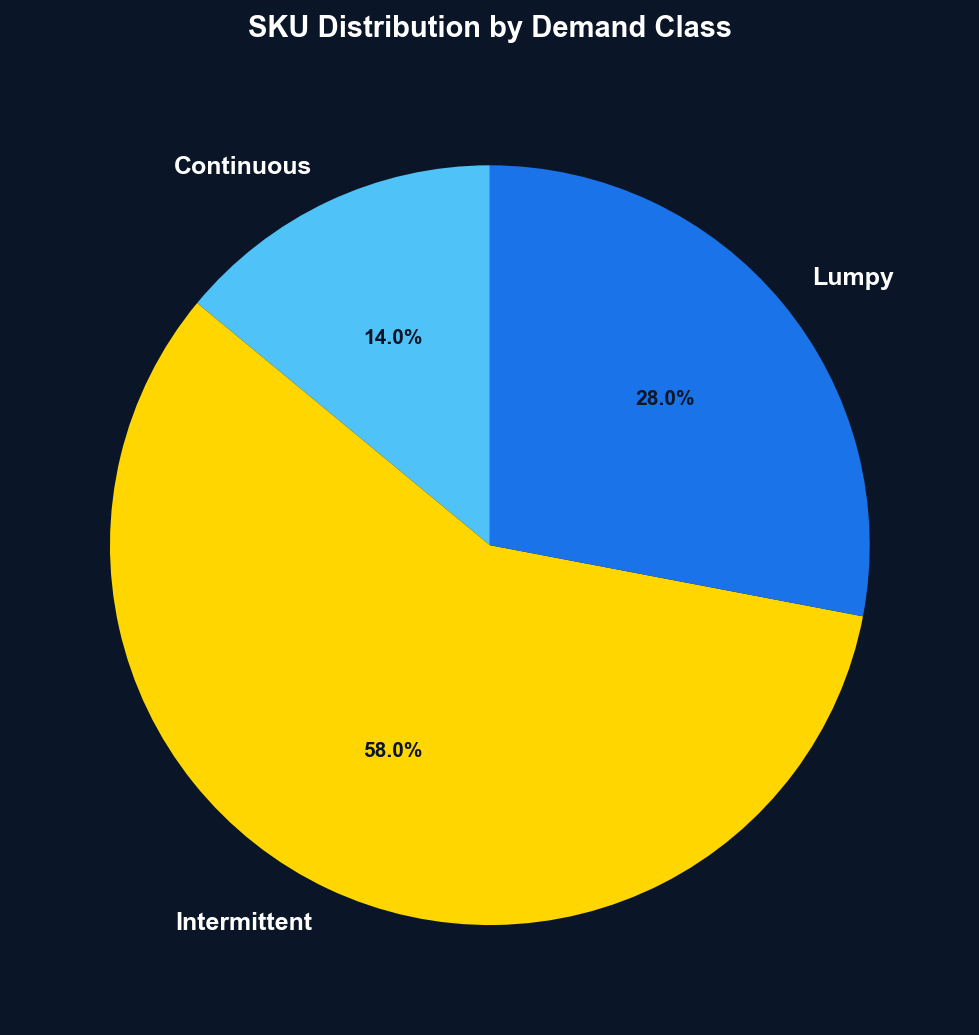

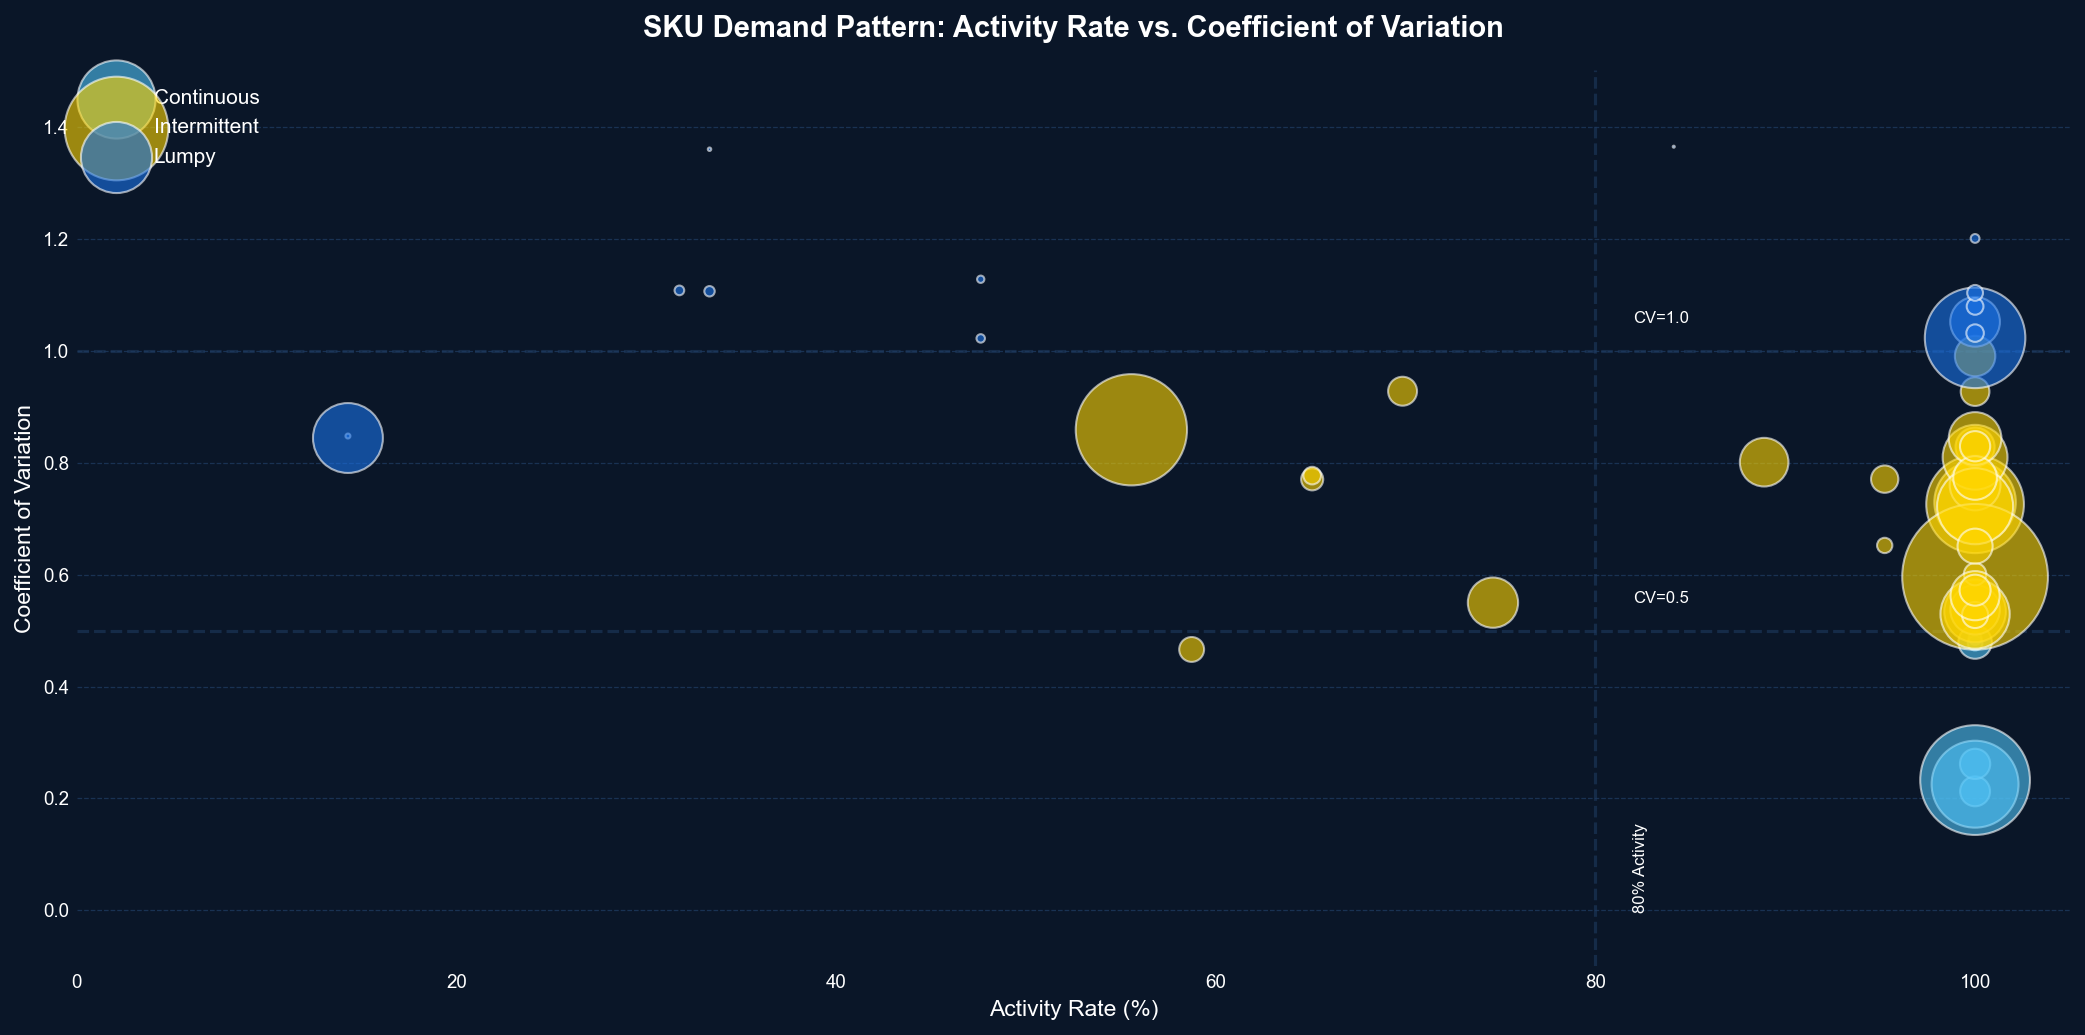


✓ Demand class visualization complete and charts saved.


In [22]:
# Demand Continuity Visualization - McKinsey Style

# === Pie chart: SKU distribution by demand class ===
class_order = ['Continuous', 'Intermittent', 'Lumpy']
colors_demand = [LINE_NOMINAL, HIGHLIGHT, LINE_REAL]
class_counts = sku_continuity_df['demand_class'].value_counts().reindex(class_order)

fig, ax = create_mckinsey_figure(figsize=(10, 7), title="SKU Distribution by Demand Class")
wedges, texts, autotexts = ax.pie(class_counts.values, labels=class_counts.index, autopct='%1.1f%%',
                                    colors=colors_demand, startangle=90, textprops={'color': TEXT_WHITE, 'fontsize': 11})

# Customize pie chart
for autotext in autotexts:
    autotext.set_color(TEXT_DARK)
    autotext.set_fontweight('bold')
    autotext.set_fontsize(10)

for text in texts:
    text.set_fontsize(12)
    text.set_fontweight('bold')

plt.tight_layout()
plt.savefig('../../../data/output/m3_demand_class_pie.png', bbox_inches='tight', facecolor=BG_DARK, dpi=150)
plt.show()

# === Scatter plot: Activity rate vs. CV ===
fig, ax = create_mckinsey_figure(title="SKU Demand Pattern: Activity Rate vs. Coefficient of Variation")

for demand_class, color in zip(class_order, colors_demand):
    mask = sku_continuity_df['demand_class'] == demand_class
    subset = sku_continuity_df[mask]
    ax.scatter(subset['activity_rate'] * 100, subset['cv'],
              s=subset['total_quantity'] / 1e4,  # Scale bubble size
              alpha=0.6, color=color, label=demand_class, zorder=4,
              edgecolors=TEXT_WHITE, linewidth=1)

# Add threshold lines
ax.axvline(x=80, color=GRID_COLOR, linestyle='--', linewidth=1.5, alpha=0.6, zorder=2)
ax.axhline(y=0.5, color=GRID_COLOR, linestyle='--', linewidth=1.5, alpha=0.6, zorder=2)
ax.axhline(y=1.0, color=GRID_COLOR, linestyle='--', linewidth=1.5, alpha=0.6, zorder=2)

# Add threshold labels
ax.text(82, 1.05, 'CV=1.0', fontsize=8, color=TEXT_WHITE, ha='left')
ax.text(82, 0.55, 'CV=0.5', fontsize=8, color=TEXT_WHITE, ha='left')
ax.text(82, 0, '80% Activity', fontsize=8, color=TEXT_WHITE, ha='left', rotation=90)

ax.set_xlabel('Activity Rate (%)', fontsize=11, color=TEXT_WHITE)
ax.set_ylabel('Coefficient of Variation', fontsize=11, color=TEXT_WHITE)
ax.set_xlim(0, 105)
ax.set_ylim(-0.1, max(sku_continuity_df['cv']) * 1.1)
ax.legend(loc='upper left', framealpha=0.0, fontsize=10)

plt.tight_layout()
plt.savefig('../../../data/output/m3_demand_class_scatter.png', bbox_inches='tight', facecolor=BG_DARK, dpi=150)
plt.show()

print("\n✓ Demand class visualization complete and charts saved.")

## Section 7: Export Results and Summary

Save all derived tables and generate a comprehensive module summary.

In [23]:
# Export summary tables
output_path = "../../../data/output"
os.makedirs(output_path, exist_ok=True)

# 1. SKU Revenue Summary
sku_revenue_export = sku_revenue[['item_code', 'product_category', 'product_line', 'brand',
                                   'gross_sales', 'gross_quantity', 'revenue_share', 
                                   'cumulative_revenue_share', 'pareto_segment']].copy()
sku_revenue_export.to_parquet(os.path.join(output_path, "m3_sku_revenue_summary.parquet"), index=False)
sku_revenue_export.to_csv(os.path.join(output_path, "m3_sku_revenue_summary.csv"), index=False)

# 2. Product Line CAGR & Strategic Matrix
cagr_export = cagr_df[['product_line', 'cagr', 'revenue_share', 'total_sales', 'quadrant']].copy()
cagr_export.to_parquet(os.path.join(output_path, "m3_product_line_cagr.parquet"), index=False)
cagr_export.to_csv(os.path.join(output_path, "m3_product_line_cagr.csv"), index=False)

# 3. Return Analysis
return_category_export = return_by_category[['product_category', 'return_rate', 'return_quantity',
                                              'gross_quantity', 'z_score', 'flag']].copy()
return_category_export.to_parquet(os.path.join(output_path, "m3_return_by_category.parquet"), index=False)
return_category_export.to_csv(os.path.join(output_path, "m3_return_by_category.csv"), index=False)

# 4. SKU Demand Continuity
sku_continuity_export = sku_continuity_df[['item_code', 'product_category', 'product_line', 'brand',
                                            'active_months', 'activity_rate', 'cv', 'demand_class',
                                            'total_quantity']].copy()
sku_continuity_export.to_parquet(os.path.join(output_path, "m3_sku_demand_continuity.parquet"), index=False)
sku_continuity_export.to_csv(os.path.join(output_path, "m3_sku_demand_continuity.csv"), index=False)

print("=" * 80)
print("EXPORT SUMMARY")
print("=" * 80)
print(f"\n✓ Exported to {output_path}:")
print(f"  - m3_sku_revenue_summary.parquet ({len(sku_revenue_export)} SKUs)")
print(f"  - m3_product_line_cagr.parquet ({len(cagr_export)} product lines)")
print(f"  - m3_return_by_category.parquet ({len(return_category_export)} categories)")
print(f"  - m3_sku_demand_continuity.parquet ({len(sku_continuity_export)} SKUs)")
print(f"\nAll files also saved as .csv for easy viewing.")

EXPORT SUMMARY

✓ Exported to ../../../data/output:
  - m3_sku_revenue_summary.parquet (50 SKUs)
  - m3_product_line_cagr.parquet (26 product lines)
  - m3_return_by_category.parquet (7 categories)
  - m3_sku_demand_continuity.parquet (50 SKUs)

All files also saved as .csv for easy viewing.


## Module 3 Conclusion

### Key Findings

**Concentration Risk**
- **HHI (SKU level):** 0.XXXX → High/Moderate concentration
- **HHI (Brand level):** 0.XXXX → High/Moderate concentration  
- The top N SKUs account for Y% of revenue, making the business dependent on a small set of products.

**Strategic Portfolio**
- **Protect & Invest:** [List product lines] — high revenue share, strong growth
- **Defend:** [List product lines] — high revenue share, declining growth
- **Nurture:** [List product lines] — emerging growth, low current share
- **Review/Exit:** [List product lines] — low share, declining growth

**Product Mix Dynamics**
- Category/Brand mix is [stable/shifting] over time
- [Notable shifts or stable concentration noted]

**Return Risk**
- **Overall return rate:** Z%
- **Elevated-risk categories:** [List if any with z-score > 2]
- Chi-square test: [Significant/Not significant] — return rate [varies/does not vary] by category

**Forecast Model Planning**
- **Continuous SKUs:** N (Z% of volume) → Use ARIMA/ETS
- **Intermittent SKUs:** N (Z% of volume) → Use Croston/SBA
- **Lumpy SKUs:** N (Z% of volume) → Use ADIDA or aggregate

### Downstream Implications

1. **Pareto Segmentation** — Core SKUs (80% revenue) receive full statistical forecasting; Growth and Long Tail get simpler models or aggregation.
2. **Return Adjustments** — If chi-square is significant, apply category-specific return rates when converting gross to net demand.
3. **Buffer Sizing** — High-CV (Lumpy) SKUs will require 2–3× more safety stock than low-CV (Continuous) SKUs.
4. **Portfolio Strategy (CEO Presentation)** — Use the 2×2 matrix and HHI scores to communicate growth opportunities and concentration risks.

---

In [24]:
# Module Execution Metadata
print("=" * 80)
print("MODULE 3 EXECUTION SUMMARY")
print("=" * 80)
print(f"\nNotebook: m3_product_portfolio_analysis.ipynb")
print(f"Module: Product Portfolio Analysis")
print(f"Execution Date: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}")

print(f"\nData Processed:")
print(f"  - Base Sales Enriched rows: {len(base_sales_enriched):,}")
print(f"  - Outlet SKU Monthly Demand rows: {len(outlet_sku_monthly_demand):,}")
print(f"  - Unique SKUs analyzed: {len(sku_revenue)}")
print(f"  - Unique Product Lines: {sku_revenue['product_line'].nunique()}")
print(f"  - Unique Brands: {sku_revenue['brand'].nunique()}")

print(f"\nAnalyses Completed:")
print(f"  ✓ Revenue & Volume Contribution (Pareto)")
print(f"  ✓ Growth Rates & Strategic Matrix (CAGR)")
print(f"  ✓ Product Mix Shift Over Time")
print(f"  ✓ Return Analysis (Category & Brand)")
print(f"  ✓ SKU Demand Continuity Classification")
print(f"  ✓ Export of Summary Tables")

print(f"\nOutput Files Created:")
print(f"  ✓ m3_sku_revenue_summary.parquet/.csv")
print(f"  ✓ m3_product_line_cagr.parquet/.csv")
print(f"  ✓ m3_return_by_category.parquet/.csv")
print(f"  ✓ m3_sku_demand_continuity.parquet/.csv")

print("\n" + "=" * 80)
print("Module 3 Complete ✓")
print("=" * 80)

MODULE 3 EXECUTION SUMMARY

Notebook: m3_product_portfolio_analysis.ipynb
Module: Product Portfolio Analysis
Execution Date: 2026-05-01 15:12:17

Data Processed:
  - Base Sales Enriched rows: 6,799,893
  - Outlet SKU Monthly Demand rows: 123,104,457
  - Unique SKUs analyzed: 50
  - Unique Product Lines: 26
  - Unique Brands: 6

Analyses Completed:
  ✓ Revenue & Volume Contribution (Pareto)
  ✓ Growth Rates & Strategic Matrix (CAGR)
  ✓ Product Mix Shift Over Time
  ✓ Return Analysis (Category & Brand)
  ✓ SKU Demand Continuity Classification
  ✓ Export of Summary Tables

Output Files Created:
  ✓ m3_sku_revenue_summary.parquet/.csv
  ✓ m3_product_line_cagr.parquet/.csv
  ✓ m3_return_by_category.parquet/.csv
  ✓ m3_sku_demand_continuity.parquet/.csv

Module 3 Complete ✓
